**Author:** Tianqi Shen & Ziye Ma & GPT-4o

**Date:** 20 June 2026

# Numerical Experiments of SOD-Escape Mechanism (Line-Search Version)
## Quadratic Neural Network on Iris Binary Classification

Recall that optimizing a Burer-Monteiro (BM) factorized matrix sensing problem is equivalent to training a two-layer quadratic neural network (https://arxiv.org/abs/1712.09203).
This notebook studies the optimization behavior of a one-hidden-layer quadratic neural network on binary classification tasks constructed from the Iris dataset. We allow any pair of Iris classes to be selected, namely Setosa, Versicolor, and Virginica. 

The model considered in this notebook is a quadratic neural network of the form
$$
    \hat{y}_i
    =
    \sum_{j=1}^{r}
    \left(
    u_j^\top x_i
    \right)^2
    =
    x_i^\top U U^\top x_i,
$$
where $x_i \in \mathbb{R}^d$ denotes the input feature vector, optionally augmented with a bias coordinate, and $U \in \mathbb{R}^{d \times r}$ is the trainable factor matrix. The parameter $r$ controls the rank, or equivalently the hidden width, of the quadratic model.

The empirical objective is the mean squared error
$$
    h(U)
    =
    \frac{1}{2N}
    \sum_{i=1}^{N}
    \left(
    \hat{y}_i - y_i
    \right)^2
    +
    \frac{\lambda}{2}
    \|U\|_F^2,
$$
where $N$ is the number of training samples, $y_i$ is the binary target label, and $\lambda \geq 0$ is an optional weight-decay parameter.

The main focus of this notebook is to evaluate a structured line-search mechanism based on second-order directional information, referred to as SOD line search. During training, full-batch gradient descent is first applied. When progress stalls according to a window-based relative loss decrease criterion, the algorithm constructs structured search directions from the matrix-space gradient
$$
    G
    =
    \frac{1}{N}
    \sum_{i=1}^{N}
    \left(
    \hat{y}_i - y_i
    \right)
    x_i x_i^\top.
$$

In particular, the SOD directions are constructed using the minimum eigenvector of $G$, together with the smallest singular directions of the current factor matrix $U$ (i.e., $\sigma_r$). A deterministic line search is then performed along the following directions to determine whether a loss-decreasing update can be found:
- $u_d q_r^\top$, where $(\lambda_d,u_d)$ are the eigenpair of $G$;
- $\sum_{i=1}^{N}\left[x_i^\top \left( u_d v_r^\top + v_r u_d^\top \right) x_i\right] x_i x_i^\top$, where $(\sigma_r,v_r,q_r)$ are the singular value-vector triples of $U$.

For comparison, this notebook also includes several baseline optimization methods:

- full-batch gradient descent only;
- gradient descent with line search along the negative gradient direction;
- gradient descent with line search along random directions;
- gradient descent with SOD-guided structured line search.

The experiments report training loss, test loss, training accuracy, test accuracy, and the accepted line-search events. This allows us to examine whether SOD-guided line search can help escape flat or stalled regions of the nonconvex optimization landscape more effectively than standard gradient-based or random search baselines.

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

### Load Hyper-parameters and MS Problem

In [2]:
# Load hyper-parameters
class Args:
    class_pair = (1, 2)  # 0: Setosa 1: Versicolor 2: Virginica
    # "zero_one": negative class -> 0, positive class -> 1
    # "smooth":   negative class -> 0.1, positive class -> 1.0
    label_mode = "zero_one"
    test_size = 0.5
    seed = 0  # 10086 is also ok
    add_bias = True
    r = 2
    init_scale = 1e-8
    weight_decay = 0.0
    max_iters = 15000
    lr = 1e-2
    method = "compare"  # "gd", "gd_sod", "gd_random", "gd_gradls", or "compare"
    # Stall detection
    stall_window = 200
    stall_tol = 1e-7
    min_iters_before_sod = 500
    sod_cooldown = 200
    accept_tol = 1e-5
    # Line search grid
    alpha_min_exp = -6
    alpha_max_exp = 2
    alpha_points_per_decade = 20
args = Args()
np.random.seed(args.seed)

### Functional helpers for loading and preprocessing dataset

In [3]:
def load_iris_binary(class_pair=(1, 2), test_size=0.3, seed=0, add_bias=True, label_mode="zero_one",):
    """
    Load Iris dataset and keep only two selected classes.

    sklearn target labels:
        0: Setosa
        1: Versicolor
        2: Virginica

    Parameters
    ----------
    class_pair : tuple of int
        The two classes to keep, e.g.
            (0, 1): Setosa vs Versicolor
            (0, 2): Setosa vs Virginica
            (1, 2): Versicolor vs Virginica

        class_pair[0] will be mapped to label 0.
        class_pair[1] will be mapped to label 1.

    test_size : float
        Test split ratio.

    seed : int
        Random seed for train/test split.

    add_bias : bool
        If True, append one bias coordinate to each x.

    label_mode : str
        "zero_one":
            class_pair[0] -> 0, class_pair[1] -> 1.
        "smooth":
            class_pair[0] -> 0.1, class_pair[1] -> 1.0.

    Returns
    -------
    X_train, y_train, X_test, y_test, meta
    """

    iris = load_iris()
    X = iris.data.astype(float)
    y_raw = iris.target.astype(int)

    target_names = iris.target_names
    class_0, class_1 = class_pair
    valid_classes = {0, 1, 2}

    if len(class_pair) != 2:
        raise ValueError("class_pair must contain exactly two class labels.")
    if class_0 not in valid_classes or class_1 not in valid_classes:
        raise ValueError("Iris class labels must be selected from {0, 1, 2}.")
    if class_0 == class_1:
        raise ValueError("class_pair must contain two different classes.")

    # Keep selected two classes.
    mask = (y_raw == class_0) | (y_raw == class_1)
    X = X[mask]
    y_raw = y_raw[mask]

    # Binary labels:  class_0 -> 0    class_1 -> 1
    y = (y_raw == class_1).astype(float)

    if label_mode == "smooth":
        y = 0.1 + 0.9 * y
    elif label_mode == "zero_one":
        pass
    else:
        raise ValueError("label_mode must be either 'zero_one' or 'smooth'.")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y,)

    # Standardize using training statistics only.
    mu = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True) + 1e-12
    X_train = (X_train - mu) / std
    X_test = (X_test - mu) / std

    if add_bias:
        X_train = np.concatenate([X_train, np.ones((X_train.shape[0], 1))], axis=1,)
        X_test = np.concatenate([X_test, np.ones((X_test.shape[0], 1))], axis=1,)

    meta = {
        "class_pair": class_pair,
        "negative_class": class_0,
        "positive_class": class_1,
        "negative_class_name": target_names[class_0],
        "positive_class_name": target_names[class_1],
        "feature_names": iris.feature_names,
        "target_names": target_names,
        "mu": mu,
        "std": std,
        "add_bias": add_bias,
        "label_mode": label_mode,
    }

    return X_train, y_train, X_test, y_test, meta

X_train, y_train, X_test, y_test, meta = load_iris_binary(class_pair=args.class_pair, test_size=args.test_size,
                                                          seed=args.seed, add_bias=args.add_bias, label_mode=args.label_mode,)

print("Data loaded:")
print(f"  Class pair: {meta['class_pair']}")
print(f"  Negative class: {meta['negative_class']} ({meta['negative_class_name']})")
print(f"  Positive class: {meta['positive_class']} ({meta['positive_class_name']})")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test  shape: {X_test.shape}")
print(f"  y_train distribution: mean={y_train.mean():.3f}")
print(f"  y_test  distribution: mean={y_test.mean():.3f}")
print(f"  model rank r: {args.r}")

Data loaded:
  Class pair: (1, 2)
  Negative class: 1 (versicolor)
  Positive class: 2 (virginica)
  X_train shape: (50, 5)
  X_test  shape: (50, 5)
  y_train distribution: mean=0.500
  y_test  distribution: mean=0.500
  model rank r: 2


### Functional helpers for quadratic network

In [4]:
def predict(U, X):
    """
    Predict using one-hidden-layer quadratic network.
    y_hat_i = sum_j (x_i^T u_j)^2

    Parameters
    ----------
    U : ndarray, shape (d, r)
    X : ndarray, shape (N, d)

    Returns
    -------
    y_hat : ndarray, shape (N,)
    """

    Z = X @ U
    y_hat = np.sum(Z ** 2, axis=1)
    return y_hat

def loss(U, X, y, weight_decay=0.0):
    """
    MSE objective: h(U) = 1/(2N) ||predict(U, X) - y||^2 + weight_decay / 2 * ||U||_F^2
    """

    residual = predict(U, X) - y
    data_loss = 0.5 * np.mean(residual ** 2)
    reg_loss = 0.5 * weight_decay * np.sum(U ** 2)
    return data_loss + reg_loss

def accuracy(U, X, y, threshold=0.5):
    """
    Classification accuracy.
    For zero-one labels, predict class 1 if y_hat >= threshold.
    """

    y_hat = predict(U, X)
    y_pred = (y_hat >= threshold).astype(float)

    # If labels are smoothed, convert them back to {0,1}.
    y_true = (y >= 0.5).astype(float)

    return np.mean(y_pred == y_true)

def matrix_gradient_G(U, X, y):
    """
    Compute matrix-space gradient G = 1/N sum_i residual_i x_i x_i^T
    where residual_i = x_i^T U U^T x_i - y_i.
    Then the factor gradient is grad_U = 2 G U.
    """

    N, d = X.shape
    residual = predict(U, X) - y

    # Efficient vectorized formula: G = X^T diag(residual) X / N
    G = (X.T * residual) @ X / N

    # Symmetrize for numerical stability.
    G = 0.5 * (G + G.T)

    return G

def grad_U(U, X, y, weight_decay=0.0):
    """
    Gradient of h(U): grad h(U) = 2 G U + weight_decay * U.
    """

    G = matrix_gradient_G(U, X, y)
    return 2.0 * G @ U + weight_decay * U

### Functional helper for SOD-Escape

In [5]:
def AstarA(B, X):
    """
    Compute A^* A(B) for sensing matrices A_i = x_i x_i^T:
        A^* A(B) = 1/N sum_i <x_i x_i^T, B> x_i x_i^T.
    Since
        <x_i x_i^T, B> = x_i^T B x_i,
    we can compute it vectorized.

    Parameters
    ----------
    B : ndarray, shape (d, d)
    X : ndarray, shape (N, d)

    Returns
    -------
    E : ndarray, shape (d, d)
    """

    N, d = X.shape

    coeff = np.einsum("ni,ij,nj->n", X, B, X)
    E = (X.T * coeff) @ X / N

    E = 0.5 * (E + E.T)
    return E

def sod_directions(U, X, y, normalize=True):
    """
    Construct SOD beta and gamma directions.

    Inputs
    ------
    U : ndarray, shape (d, r)
        Current factor.
    X : ndarray, shape (N, d)
        Training features with bias.
    y : ndarray, shape (N,)
        Training labels.

    Returns
    -------
    info : dict
        Contains:
            D_beta, D_gamma, lambda_min, sigma_min, u_min, v_min, q_min, G, E

    Definition
    ----------
    Let G = 1/N sum_i residual_i x_i x_i^T.
    Let u_min be the minimum eigenvector of G.
    Let U = V Sigma Q^T and take v_min, q_min corresponding to the smallest singular value.
    Then D_beta = u_min q_min^T.
    Define B = u_min v_min^T + v_min u_min^T, and E = A^* A(B).
    Then D_gamma = E U.
    """

    d, r = U.shape

    # Matrix-space gradient.
    G = matrix_gradient_G(U, X, y)

    # Minimum eigenpair of G.
    eigvals, eigvecs = np.linalg.eigh(G)
    idx_min = np.argmin(eigvals)
    lambda_min = eigvals[idx_min]
    u_min = eigvecs[:, idx_min:idx_min + 1]

    # SVD of U.  U = V diag(S) QT
    V, S, QT = np.linalg.svd(U, full_matrices=False)

    # Smallest singular direction.
    v_min = V[:, -1:]
    q_min = QT.T[:, -1:]
    sigma_min = S[-1]

    # Beta direction.
    D_beta = u_min @ q_min.T

    # Gamma direction.
    B = u_min @ v_min.T + v_min @ u_min.T
    E = AstarA(B, X)
    D_gamma = E @ U

    if normalize:
        D_beta_norm = np.linalg.norm(D_beta, ord="fro")
        D_gamma_norm = np.linalg.norm(D_gamma, ord="fro")
        D_beta = D_beta / (D_beta_norm + 1e-12)
        D_gamma = D_gamma / (D_gamma_norm + 1e-12)

    return {"D_beta": D_beta, "D_gamma": D_gamma,
            "lambda_min": lambda_min, "sigma_min": sigma_min,
            "u_min": u_min, "v_min": v_min, "q_min": q_min,
            "G": G, "E": E,}

### Functional helper for line-search methods

In [6]:
def make_symmetric_log_grid(min_exp=-6, max_exp=2, points_per_decade=3,):
    """
    Make symmetric logarithmic line-search grid.

    Example:
        positive grid roughly contains:
            1e-6, 2.15e-6, 4.64e-6, ..., 1e2

    Returns both positive and negative values.
    """

    num = (max_exp - min_exp) * points_per_decade + 1
    positive = np.logspace(min_exp, max_exp, num=num)
    #grid = np.concatenate([positive, -positive])
    #return grid
    return positive

def line_search_along_directions(U, X, y, directions, 
                                 direction_names=None, alpha_grid=None, relative_to_U=True, weight_decay=0.0,):
    """
    Generic deterministic line-search over a list of directions.
    Candidate: U_candidate = U + alpha * scale * D
    where scale = max(||U||_F, 1e-3) if relative_to_U is True.
    """

    if alpha_grid is None:
        alpha_grid = make_symmetric_log_grid(min_exp=-6, max_exp=2, points_per_decade=3,)

    if direction_names is None:
        direction_names = [f"dir_{k}" for k in range(len(directions))]

    current_loss = loss(U, X, y, weight_decay=weight_decay)

    scale = max(np.linalg.norm(U, ord="fro"), 1e-3) if relative_to_U else 1.0

    best_U = U.copy()
    best_loss = current_loss
    best_direction = "none"
    best_alpha = 0.0

    for name, D in zip(direction_names, directions):
        D_norm = np.linalg.norm(D, ord="fro")
        if D_norm < 1e-14:
            continue

        for alpha in alpha_grid:
            step = alpha * scale
            U_candidate = U + step * D
            val = loss(U_candidate, X, y, weight_decay=weight_decay)

            if val < best_loss:
                best_loss = val
                best_U = U_candidate.copy()
                best_direction = name
                best_alpha = step

    return {
        "best_U": best_U, "best_loss": best_loss, "best_direction": best_direction, "best_alpha": best_alpha,
        "current_loss": current_loss, "accepted": best_loss < current_loss,
    }

def sod_line_search(U, X, y, alpha_grid=None, relative_to_U=True, weight_decay=0.0, use_beta=True, use_gamma=True,):
    """
    SOD-guided structured line-search.
    Uses D_beta and/or D_gamma.
    """

    sod_info = sod_directions(U, X, y, normalize=True)

    directions = []
    names = []

    if use_beta:
        directions.append(sod_info["D_beta"])
        names.append("SOD-beta")
        
    if use_gamma:
        directions.append(sod_info["D_gamma"])
        names.append("SOD-gamma")

    ls_result = line_search_along_directions(U=U, X=X, y=y, directions=directions, direction_names=names,
                                             alpha_grid=alpha_grid, relative_to_U=relative_to_U, weight_decay=weight_decay,)

    ls_result.update({"lambda_min": sod_info["lambda_min"], "sigma_min": sod_info["sigma_min"],})

    return ls_result

def random_line_search(U, X, y, rng, num_random_dirs=2, alpha_grid=None, relative_to_U=True, weight_decay=0.0,):
    """
    Random direction line-search baseline.
    """

    directions = []
    names = []

    for k in range(num_random_dirs):
        D = rng.normal(size=U.shape)
        D = D / (np.linalg.norm(D, ord="fro") + 1e-12)
        directions.append(D)
        names.append(f"Random-{k}")

    return line_search_along_directions(U=U, X=X, y=y, directions=directions, direction_names=names,
                                        alpha_grid=alpha_grid, relative_to_U=relative_to_U, weight_decay=weight_decay,)

def gradient_line_search(U, X, y, weight_decay=0.0, alpha_grid=None, relative_to_U=True,):
    """
    Gradient line-search baseline along -grad h(U).
    """

    D = -grad_U(U, X, y, weight_decay=weight_decay)
    D = D / (np.linalg.norm(D, ord="fro") + 1e-12)

    return line_search_along_directions(U=U, X=X, y=y, directions=[D], direction_names=["Negative-gradient"],
                                        alpha_grid=alpha_grid, relative_to_U=relative_to_U, weight_decay=weight_decay,)

### Functional helpers for training

In [7]:
# Training loop with stall detection and SOD-LS
def train_quadratic_network(X_train, y_train, X_test, y_test, r=1,
                            max_iters=10000, lr=1e-2, init_scale=1e-2, seed=0, weight_decay=0.0, method="gd_sod",
                            stall_window=200, stall_tol=1e-6, min_iters_before_sod=500, sod_cooldown=200, accept_tol=1e-12,
                            alpha_min_exp=-6, alpha_max_exp=2, alpha_points_per_decade=3,):
    """
    Train one-hidden-layer quadratic network.

    method options:
        "gd": Full-batch GD only.
        "gd_sod": Full-batch GD. When stalled, apply SOD line-search.
        "gd_random": Full-batch GD. When stalled, apply random direction line-search.
        "gd_gradls": Full-batch GD. When stalled, apply negative-gradient line-search.
    """

    rng = np.random.default_rng(seed)

    N, d = X_train.shape

    # Initialize U.
    U = init_scale * rng.normal(size=(d, r))

    alpha_grid = make_symmetric_log_grid(min_exp=alpha_min_exp, max_exp=alpha_max_exp,
                                         points_per_decade=alpha_points_per_decade,)
    #print("alpha_grid:", alpha_grid)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    event_log = []
    last_sod_iter = -10**12

    for t in range(max_iters + 1):
        train_loss_t = loss(U, X_train, y_train, weight_decay=weight_decay)
        test_loss_t = loss(U, X_test, y_test, weight_decay=0.0)

        train_losses.append(train_loss_t)
        test_losses.append(test_loss_t)
        train_accs.append(accuracy(U, X_train, y_train))
        test_accs.append(accuracy(U, X_test, y_test))

        if t % max(1, max_iters // 100) == 0:
            print(
                f"[{method}] iter={t:6d} "
                f"train_loss={train_loss_t:.6e} "
                f"test_loss={test_loss_t:.6e} "
                f"train_acc={train_accs[-1]:.3f} "
                f"test_acc={test_accs[-1]:.3f}"
            )

        if t == max_iters:
            break

        # Full-batch GD update.
        g = grad_U(U, X_train, y_train, weight_decay=weight_decay)
        U = U - lr * g

        # Stall detection after the GD step.
        should_check_stall = (
            t >= min_iters_before_sod and t >= stall_window and t - last_sod_iter >= sod_cooldown 
            and method in ["gd_sod", "gd_random", "gd_gradls"]
        )

        if should_check_stall:
            old_loss = train_losses[-stall_window]
            new_loss = train_losses[-1]
            relative_drop = (old_loss - new_loss) / max(old_loss, 1e-12)
            if relative_drop < stall_tol:
                before_loss = loss(U, X_train, y_train, weight_decay=weight_decay)

                if method == "gd_sod":
                    ls_result = sod_line_search(U=U, X=X_train, y=y_train, 
                                                alpha_grid=alpha_grid, relative_to_U=True, weight_decay=weight_decay,
                                                use_beta=True, use_gamma=True,)
                elif method == "gd_random":
                    ls_result = random_line_search(U=U, X=X_train, y=y_train, rng=rng, num_random_dirs=50,
                                                   alpha_grid=alpha_grid, relative_to_U=True, weight_decay=weight_decay,)
                elif method == "gd_gradls":
                    ls_result = gradient_line_search(U=U, X=X_train, y=y_train,
                                                     weight_decay=weight_decay, alpha_grid=alpha_grid, relative_to_U=True,)
                else:
                    raise RuntimeError("Unknown line-search method.")

                after_loss = ls_result["best_loss"]
                improvement = before_loss - after_loss

                accepted = improvement > accept_tol

                event = {
                    "iter": t,
                    "method": method,
                    "relative_drop_window": relative_drop,
                    "before_loss": before_loss,
                    "after_loss": after_loss,
                    "improvement": improvement,
                    "accepted": accepted,
                    "direction": ls_result["best_direction"],
                    "alpha": ls_result["best_alpha"],
                }

                if "lambda_min" in ls_result:
                    event["lambda_min"] = ls_result["lambda_min"]
                    event["sigma_min"] = ls_result["sigma_min"]

                event_log.append(event)

                if accepted:
                    U = ls_result["best_U"]
                    last_sod_iter = t

                    print("-" * 80)
                    print(f"Stall detected at iter={t}. "
                          f"window_relative_drop={relative_drop:.3e}")
                    print(f"Line-search method={method}, "
                          f"direction={ls_result['best_direction']}, "
                          f"alpha={ls_result['best_alpha']:.3e}")
                    print(f"before_loss={before_loss:.6e}, "
                          f"after_loss={after_loss:.6e}, "
                          f"improvement={improvement:.6e}, "
                          f"accepted={accepted}")
                    if "lambda_min" in ls_result:
                        print(f"lambda_min(G)={ls_result['lambda_min']:.6e}, "
                              f"sigma_min(U)={ls_result['sigma_min']:.6e}")
                    print("-" * 80)

    result = {
        "U": U,
        "train_losses": np.array(train_losses),
        "test_losses": np.array(test_losses),
        "train_accs": np.array(train_accs),
        "test_accs": np.array(test_accs),
        "event_log": event_log,
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
        "final_train_acc": train_accs[-1],
        "final_test_acc": test_accs[-1],
        "method": method,
        "r": r,
        "seed": seed,
    }

    return result

### Run simulation

In [8]:
if args.method == "compare":
    methods = ["gd", "gd_gradls", "gd_random", "gd_sod"]
    methods_color = {"gd": "blue", "gd_gradls": "orange", "gd_random": "red", "gd_sod": "green"}
else:
    methods = [args.method]

results = []

for method in methods:
    print("\n" + "#" * 100)
    print(f"Running method: {method}")
    print("#" * 100)

    res = train_quadratic_network(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        r=args.r,
        max_iters=args.max_iters,
        lr=args.lr,
        init_scale=args.init_scale,
        seed=args.seed,
        weight_decay=args.weight_decay,
        method=method,
        stall_window=args.stall_window,
        stall_tol=args.stall_tol,
        min_iters_before_sod=args.min_iters_before_sod,
        sod_cooldown=args.sod_cooldown,
        accept_tol=args.accept_tol,
        alpha_min_exp=args.alpha_min_exp,
        alpha_max_exp=args.alpha_max_exp,
        alpha_points_per_decade=args.alpha_points_per_decade,
    )

    results.append(res)


####################################################################################################
Running method: gd
####################################################################################################
[gd] iter=     0 train_loss=2.500000e-01 test_loss=2.500000e-01 train_acc=0.500 test_acc=0.500
[gd] iter=   150 train_loss=2.500000e-01 test_loss=2.500000e-01 train_acc=0.500 test_acc=0.500
[gd] iter=   300 train_loss=2.500000e-01 test_loss=2.500000e-01 train_acc=0.500 test_acc=0.500
[gd] iter=   450 train_loss=2.495440e-01 test_loss=2.493079e-01 train_acc=0.500 test_acc=0.500
[gd] iter=   600 train_loss=1.131806e-01 test_loss=9.283289e-02 train_acc=0.700 test_acc=0.800
[gd] iter=   750 train_loss=4.794735e-02 test_loss=5.234757e-02 train_acc=0.860 test_acc=0.900
[gd] iter=   900 train_loss=3.459068e-02 test_loss=4.283485e-02 train_acc=0.920 test_acc=0.940
[gd] iter=  1050 train_loss=3.328241e-02 test_loss=4.055350e-02 train_acc=0.940 test_acc=0.940
[gd] iter=  1200 t

[gd_gradls] iter=  5100 train_loss=3.215212e-02 test_loss=3.978370e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  5250 train_loss=3.215212e-02 test_loss=3.978397e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  5400 train_loss=3.215212e-02 test_loss=3.978418e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  5550 train_loss=3.215212e-02 test_loss=3.978434e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  5700 train_loss=3.215212e-02 test_loss=3.978446e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  5850 train_loss=3.215212e-02 test_loss=3.978456e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  6000 train_loss=3.215212e-02 test_loss=3.978463e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  6150 train_loss=3.215212e-02 test_loss=3.978468e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  6300 train_loss=3.215212e-02 test_loss=3.978473e-02 train_acc=0.920 test_acc=0.960
[gd_gradls] iter=  6450 train_loss=3.215212e-02 test_loss=3.978476e-02 train_acc=0

[gd_random] iter=  1950 train_loss=3.219407e-02 test_loss=3.954667e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  2100 train_loss=3.217670e-02 test_loss=3.959069e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  2250 train_loss=3.216655e-02 test_loss=3.962934e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  2400 train_loss=3.216060e-02 test_loss=3.966174e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  2550 train_loss=3.215710e-02 test_loss=3.968818e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  2700 train_loss=3.215505e-02 test_loss=3.970938e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  2850 train_loss=3.215384e-02 test_loss=3.972617e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  3000 train_loss=3.215313e-02 test_loss=3.973937e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  3150 train_loss=3.215272e-02 test_loss=3.974968e-02 train_acc=0.920 test_acc=0.960
[gd_random] iter=  3300 train_loss=3.215247e-02 test_loss=3.975770e-02 train_acc=0

--------------------------------------------------------------------------------
Stall detected at iter=4639. window_relative_drop=9.978e-08
Line-search method=gd_sod, direction=SOD-beta, alpha=4.191e-01
before_loss=3.215212e-02, after_loss=3.060907e-02, improvement=1.543052e-03, accepted=True
lambda_min(G)=-1.822325e-02, sigma_min(U)=7.928189e-07
--------------------------------------------------------------------------------
[gd_sod] iter=  4650 train_loss=3.012017e-02 test_loss=4.136728e-02 train_acc=0.960 test_acc=0.960
[gd_sod] iter=  4800 train_loss=2.969790e-02 test_loss=3.926639e-02 train_acc=0.940 test_acc=0.960
[gd_sod] iter=  4950 train_loss=2.959967e-02 test_loss=3.934555e-02 train_acc=0.940 test_acc=0.960
[gd_sod] iter=  5100 train_loss=2.950942e-02 test_loss=3.943169e-02 train_acc=0.940 test_acc=0.960
[gd_sod] iter=  5250 train_loss=2.942479e-02 test_loss=3.949564e-02 train_acc=0.940 test_acc=0.940
[gd_sod] iter=  5400 train_loss=2.934544e-02 test_loss=3.954823e-02 train_

### Visualize the results

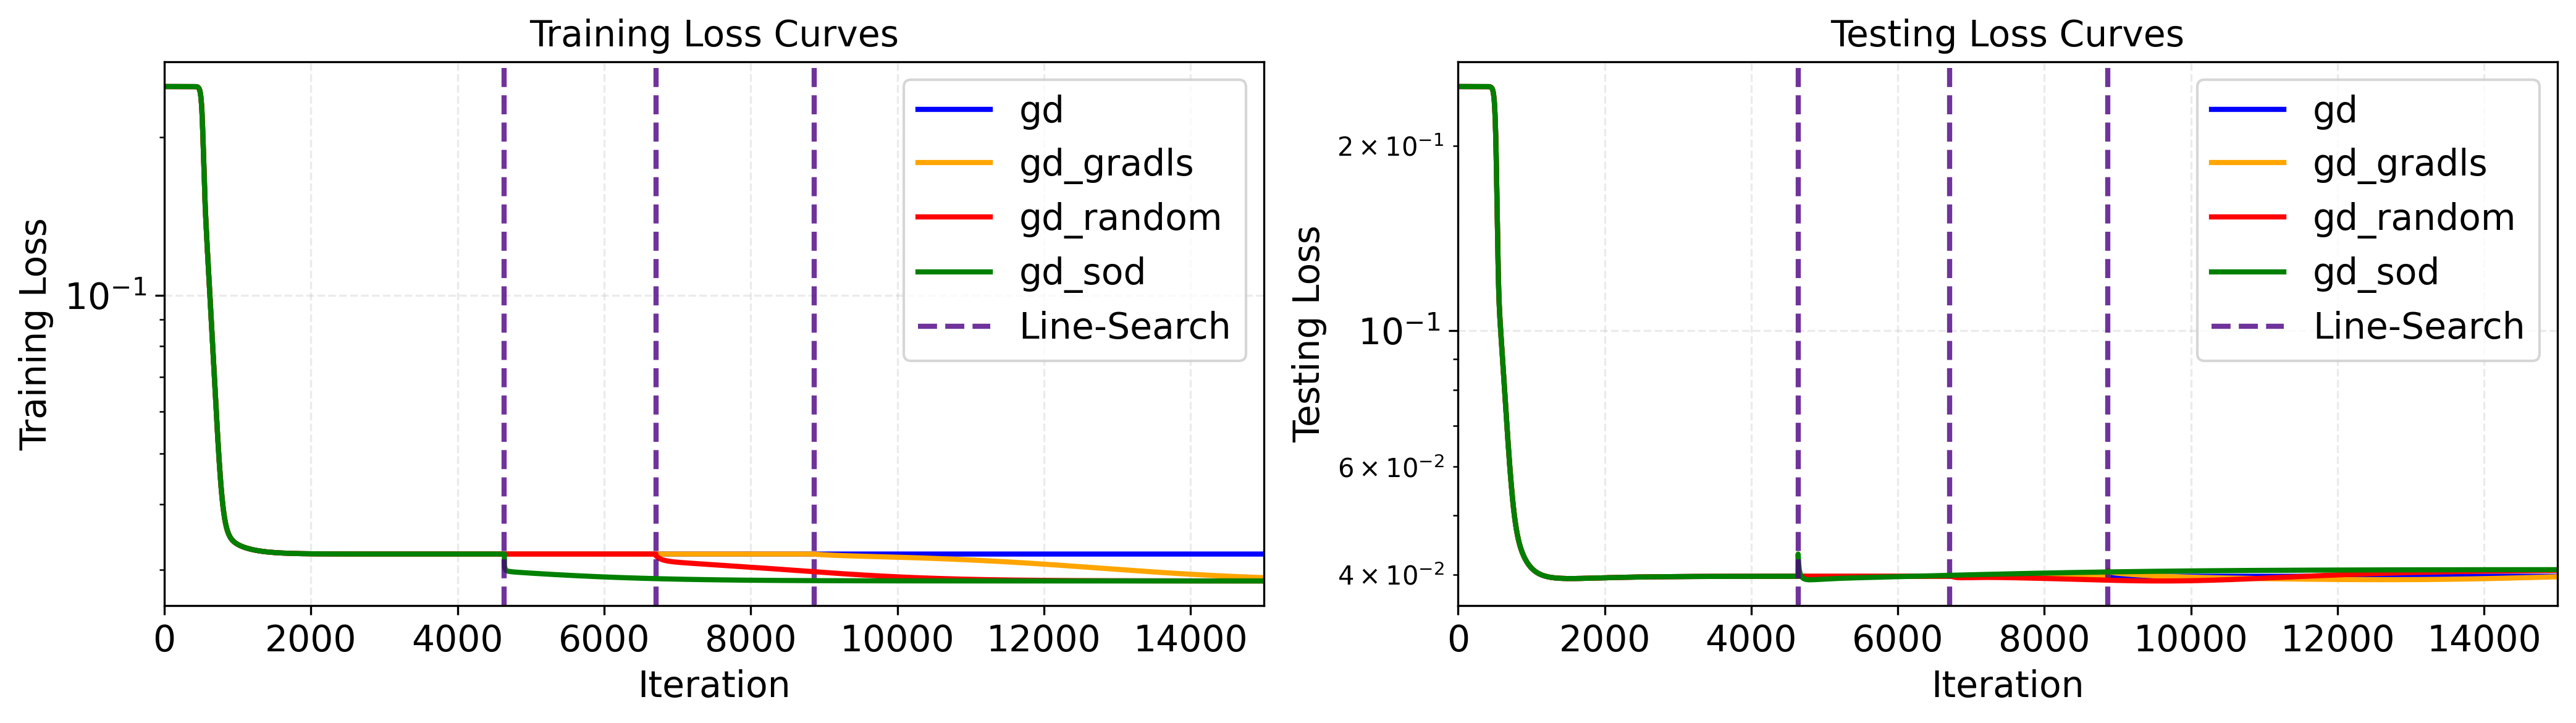

Saved figure to: quadratic_nn_linesearch_loss.pdf


In [15]:
fig0, (ax00, ax01) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

for res in results:
    train_losses = res["train_losses"]
    test_losses = res["test_losses"]
    method = res["method"]
    seed = res["seed"]
#     print(train_losses.shape)
#     ax00.semilogy(train_losses, label=f"{method}, seed={seed}", linewidth=2)
#     ax01.semilogy(test_losses, label=f"{method}, seed={seed}", linewidth=2)
#     ax00.semilogy(train_losses[:12000], label=f"{method}", linewidth=2)
#     ax01.semilogy(test_losses[:12000], label=f"{method}", linewidth=2)
    ax00.semilogy(train_losses, label=f"{method}", linewidth=2, color=methods_color[method])
    ax01.semilogy(test_losses, label=f"{method}", linewidth=2, color=methods_color[method])
    
    # Mark accepted events.
    for idx, ev in enumerate(res["event_log"]):
        if ev["accepted"]:
            if idx == 0:
                ax00.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2, label="Line-Search")
                ax01.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2, label="Line-Search")
            else:
                ax00.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2)
                ax01.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2)

ax00.set_xlabel("Iteration", fontsize=14)
ax00.set_ylabel("Training Loss", fontsize=14)
ax00.grid(True, alpha=0.25, linestyle="--")
#ax00.set_ylim(0.4, 1)
ax00.set_xlim(0, args.max_iters)
ax00.legend(loc="upper right", frameon=True, fontsize=14)
ax00.tick_params(axis='both', labelsize=14)
ax00.set_title("Training Loss Curves", fontsize=14)

ax01.set_xlabel("Iteration", fontsize=14)
ax01.set_ylabel("Testing Loss", fontsize=14)
ax01.grid(True, alpha=0.25, linestyle="--")
#ax01.set_ylim(0.4, 1)
ax01.set_xlim(0, args.max_iters)
ax01.legend(loc="upper right", frameon=True, fontsize=14)
ax01.tick_params(axis='both', labelsize=14)
ax01.set_title("Testing Loss Curves", fontsize=14) 

fig0.tight_layout()
plt.show()
fig0.savefig("quadratic_nn_linesearch_loss.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: quadratic_nn_linesearch_loss.pdf")

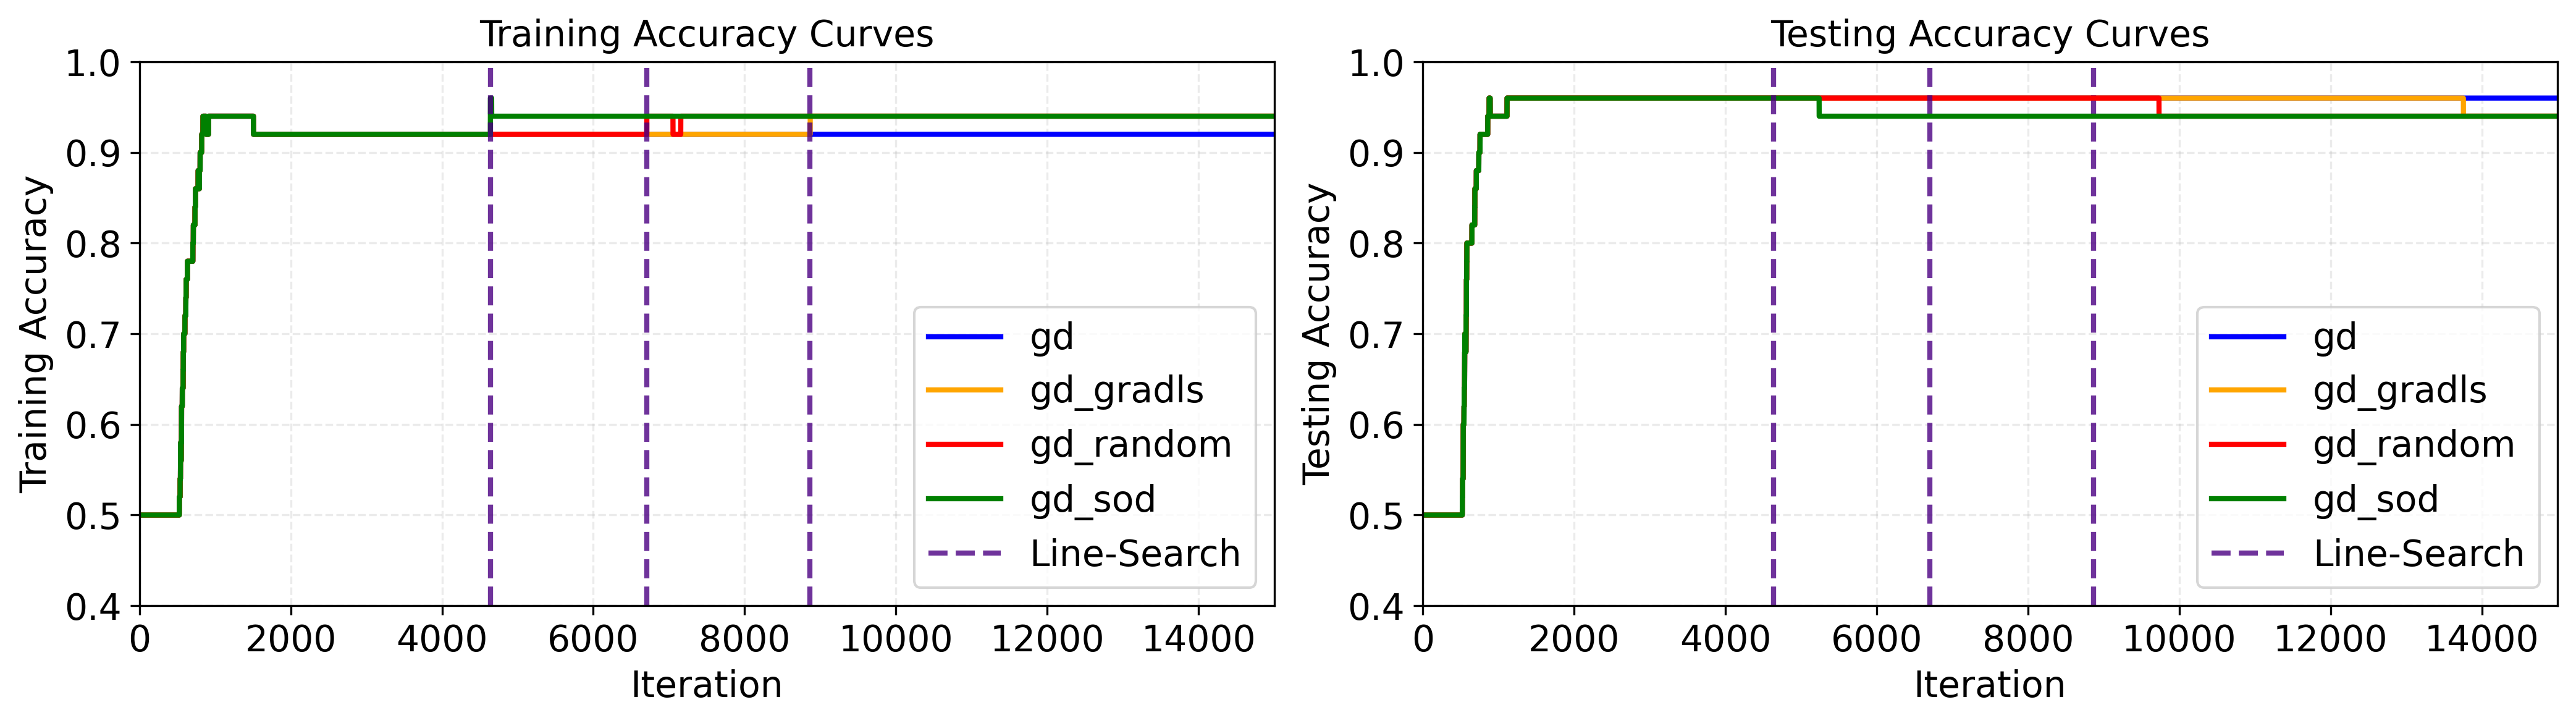

Saved figure to: quadratic_nn_linesearch_accuracy.pdf


In [16]:
fig1, (ax10, ax11) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

for res in results:
    method = res["method"]
    seed = res["seed"]

#     ax10.plot(res["train_accs"], label=f"{method}, seed={seed}, train", linewidth=2,)
#     ax11.plot(res["test_accs"], label=f"{method}, seed={seed}, test", linewidth=2,)
    ax10.plot(res["train_accs"], label=f"{method}", linewidth=2, color=methods_color[method])
    ax11.plot(res["test_accs"], label=f"{method}", linewidth=2, color=methods_color[method])
    
    # Mark accepted events.
    for idx, ev in enumerate(res["event_log"]):
        if ev["accepted"]:
            if idx == 0:
                ax10.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2, label="Line-Search")
                ax11.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2, label="Line-Search")
            else:
                ax10.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2)
                ax11.axvline(ev["iter"], color="#4B0082", alpha=0.8, linestyle="--", linewidth=2)

ax10.set_xlabel("Iteration", fontsize=14)
ax10.set_ylabel("Training Accuracy", fontsize=14)
ax10.grid(True, alpha=0.25, linestyle="--")
ax10.set_ylim(0.4, 1)
ax10.set_xlim(0, args.max_iters)
ax10.legend(loc="lower right", frameon=True, fontsize=14)
ax10.tick_params(axis='both', labelsize=14)
ax10.set_title("Training Accuracy Curves", fontsize=14)

ax11.set_xlabel("Iteration", fontsize=14)
ax11.set_ylabel("Testing Accuracy", fontsize=14)
ax11.grid(True, alpha=0.25, linestyle="--")
ax11.set_ylim(0.4, 1)
ax11.set_xlim(0, args.max_iters)
ax11.legend(loc="lower right", frameon=True, fontsize=14)
ax11.tick_params(axis='both', labelsize=14)
ax11.set_title("Testing Accuracy Curves", fontsize=14) 

fig1.tight_layout()
plt.show()
fig1.savefig("quadratic_nn_linesearch_accuracy.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: quadratic_nn_linesearch_accuracy.pdf")